In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from v2_data_preparation import load_and_prepare_data, slice_by_dates, process_insitu

In [3]:
manual_obs = load_and_prepare_data(
    filepath='../data/raw/piezometers/obs_manuales.csv',
    index_col='fecha'
)
sdh1 = process_insitu(
    filepath='../data/processed/in-situ/SDH1_daily-insitu-data.csv',
    cols_to_keep=['SDH1PS01_gw-depth_m', 'SDH1PS02_gw-depth_m', 'SDH1PS03_gw-depth_m', 'SDH1PS04_gw-depth_m']
)
sdh2 = process_insitu(
    filepath='../data/processed/in-situ/SDH2_daily-insitu-data.csv',
    cols_to_keep=['SDH2PP01_gw-depth_m', 'SDH2PS01_gw-depth_m', 'SDH2PS02_gw-depth_m', 'SDH2PS03_gw-depth_m']
)

In [4]:
sdh1 = slice_by_dates(sdh1, '2024-05-24', '2026-07-28')
sdh2 = slice_by_dates(sdh2, '2024-05-24', '2026-07-28')

In [5]:
manual_obs = (manual_obs / 100) * -1

In [6]:
manual_obs

,SDH1PS01,SDH1PS02,SDH1PS03,SDH1PS04,SDH2PP01,SDH2PS02,SDH2PS03
fecha,,,,,,,
2025-05-01,-0.500,NaN,NaN,NaN,-0.63,NaN,NaN
2026-05-16,NaN,NaN,NaN,NaN,-0.39,-1.14,NaN
2026-05-17,-0.560,-0.514,-0.421,-0.472,NaN,NaN,NaN
2026-07-28,-0.375,-0.415,-0.278,-0.318,NaN,NaN,NaN
2026-07-29,NaN,NaN,NaN,NaN,NaN,-1.15,-0.97


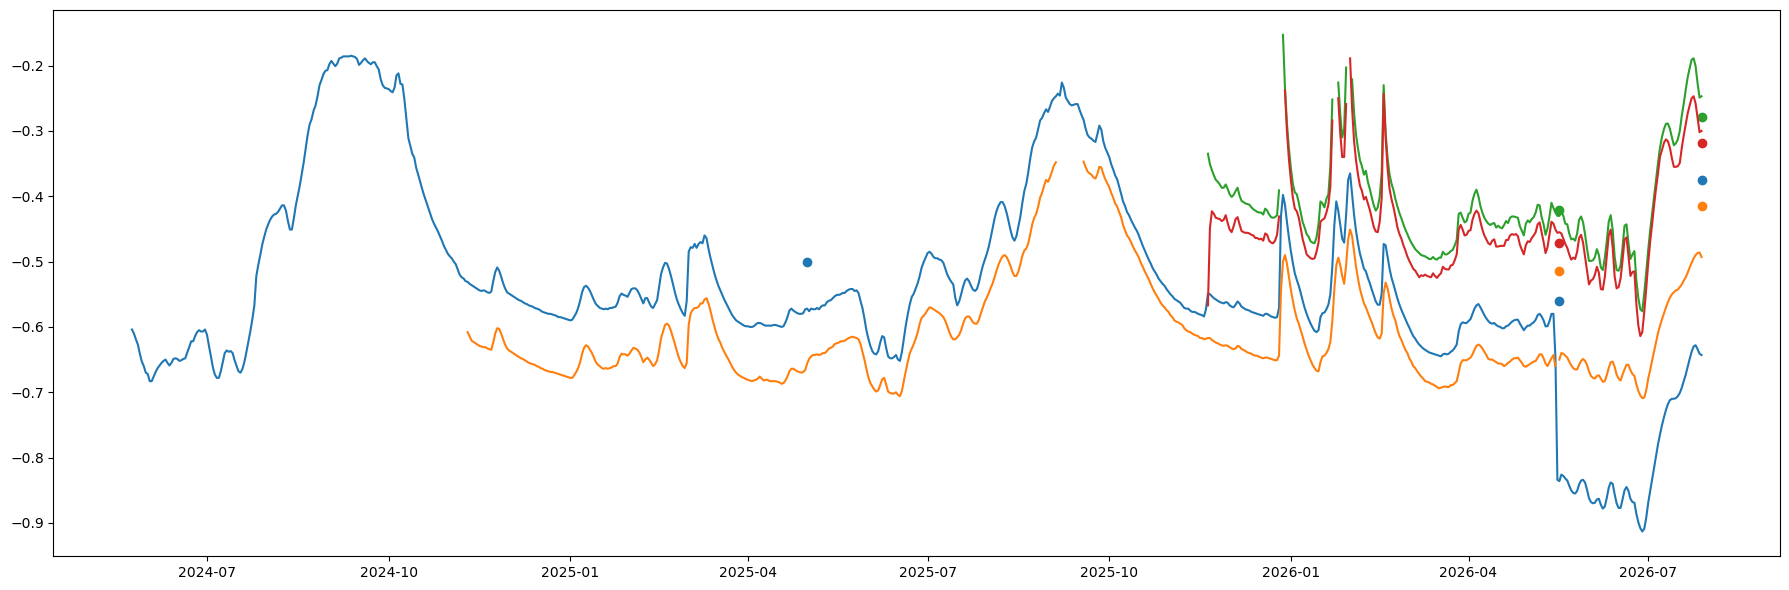

In [7]:
fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(sdh1.index, sdh1['SDH1PS01_gw-depth_m'])
ax1.plot(sdh1.index, sdh1['SDH1PS02_gw-depth_m'])
ax1.plot(sdh1.index, sdh1['SDH1PS03_gw-depth_m'])
ax1.plot(sdh1.index, sdh1['SDH1PS04_gw-depth_m'])

ax1.scatter(manual_obs.index, manual_obs['SDH1PS01'])
ax1.scatter(manual_obs.index, manual_obs['SDH1PS02'])
ax1.scatter(manual_obs.index, manual_obs['SDH1PS03'])
ax1.scatter(manual_obs.index, manual_obs['SDH1PS04'])


plt.tight_layout()
plt.show()

In [8]:
tail = sdh1['SDH1PS01_gw-depth_m'].tail(74) + 0.25

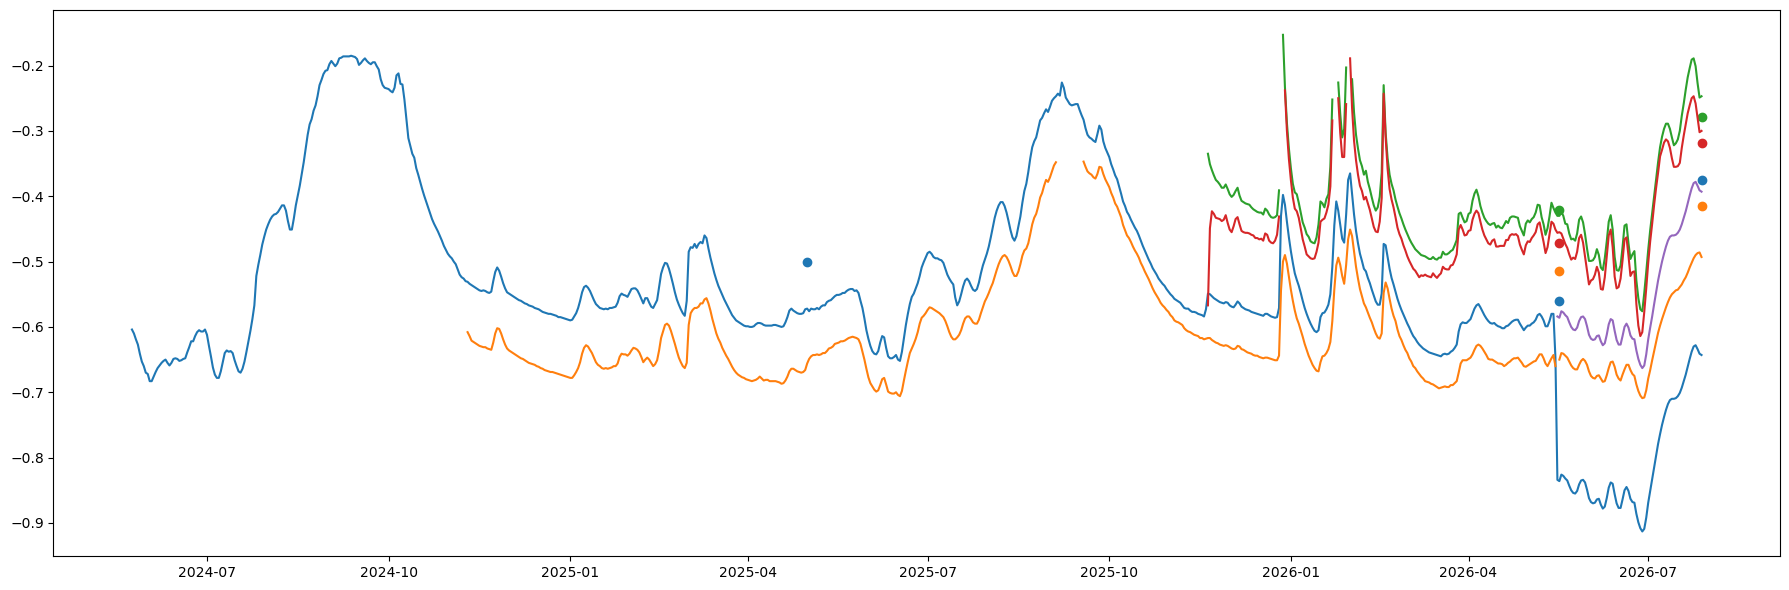

In [9]:
fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(sdh1.index, sdh1['SDH1PS01_gw-depth_m'])
ax1.plot(sdh1.index, sdh1['SDH1PS02_gw-depth_m'])
ax1.plot(sdh1.index, sdh1['SDH1PS03_gw-depth_m'])
ax1.plot(sdh1.index, sdh1['SDH1PS04_gw-depth_m'])
ax1.plot(tail.index, tail)

ax1.scatter(manual_obs.index, manual_obs['SDH1PS01'])
ax1.scatter(manual_obs.index, manual_obs['SDH1PS02'])
ax1.scatter(manual_obs.index, manual_obs['SDH1PS03'])
ax1.scatter(manual_obs.index, manual_obs['SDH1PS04'])


plt.tight_layout()
plt.show()

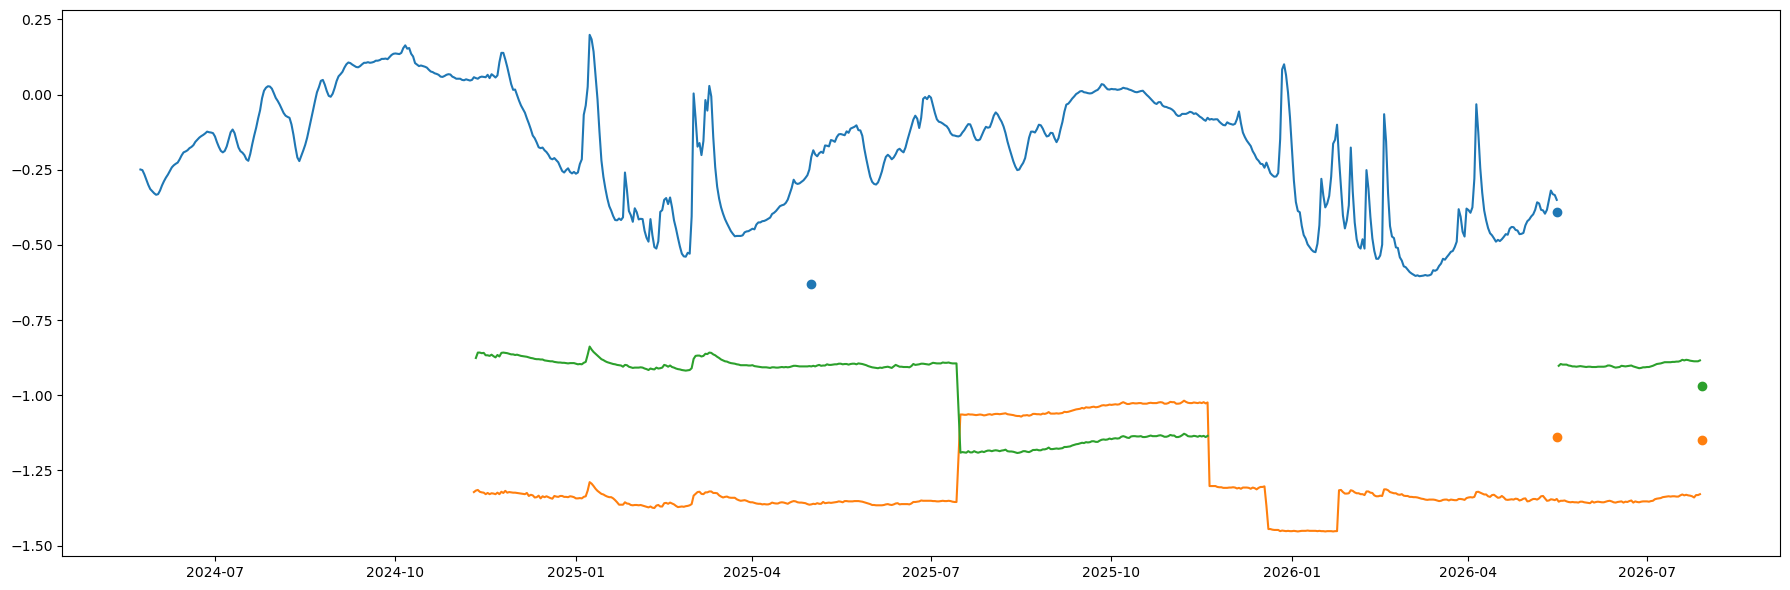

In [10]:
fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(sdh2.index, sdh2['SDH2PP01_gw-depth_m'])
# ax1.plot(sdh2.index, sdh2['SDH2PS01_gw-depth_m'])
ax1.plot(sdh2.index, sdh2['SDH2PS02_gw-depth_m'])
ax1.plot(sdh2.index, sdh2['SDH2PS03_gw-depth_m'])


ax1.scatter(manual_obs.index, manual_obs['SDH2PP01'])
ax1.scatter(manual_obs.index, manual_obs['SDH2PS02'])
ax1.scatter(manual_obs.index, manual_obs['SDH2PS03'])

plt.tight_layout()
plt.show()

/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_23648/2224912824.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


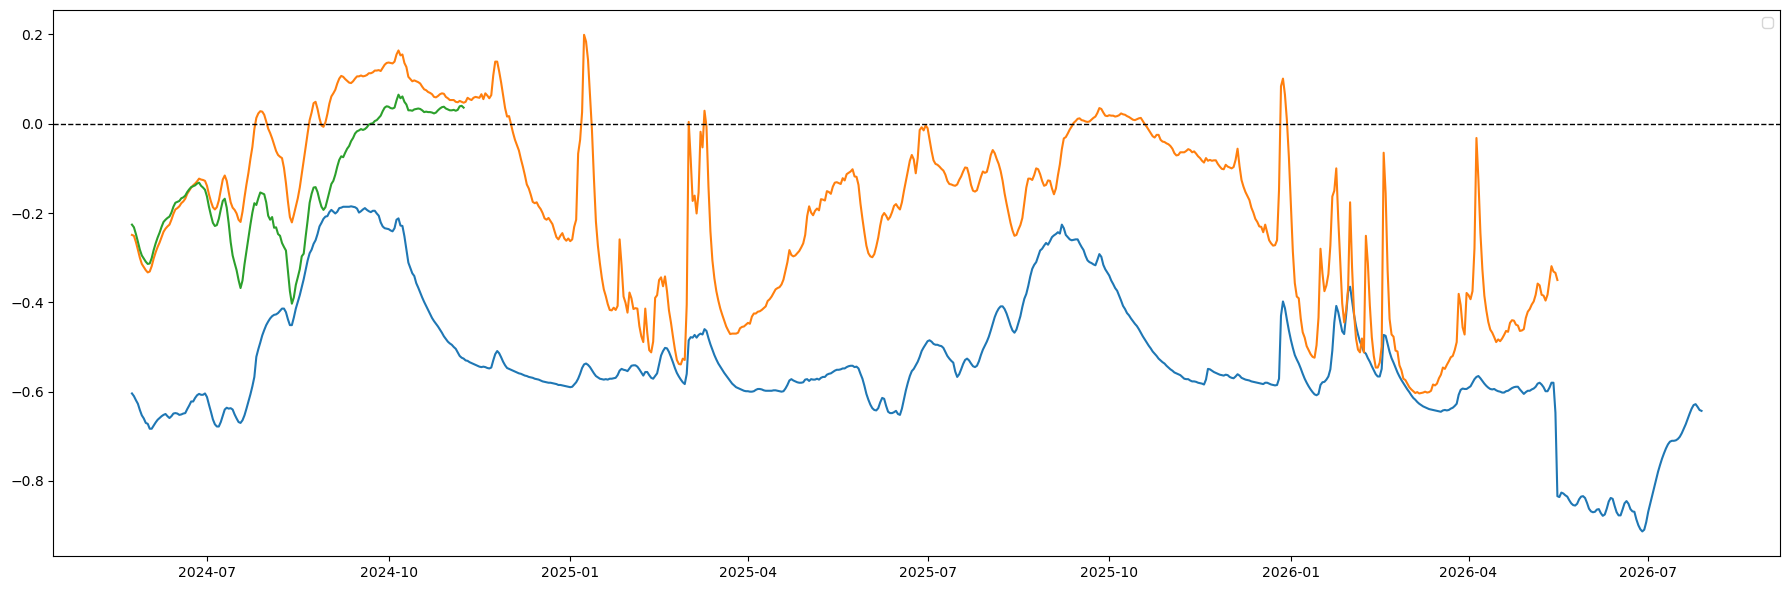

In [23]:
fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(sdh1.index, sdh1['SDH1PS01_gw-depth_m'])
ax1.plot(sdh2.index, sdh2['SDH2PP01_gw-depth_m'])
ax1.plot(sdh2.index, sdh2['SDH2PS01_gw-depth_m'])
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax1.legend()

plt.tight_layout()
plt.show()

In [12]:
sdh1_diff = sdh1.diff()#.diff()
sdh2_diff = sdh2.diff()#.diff()

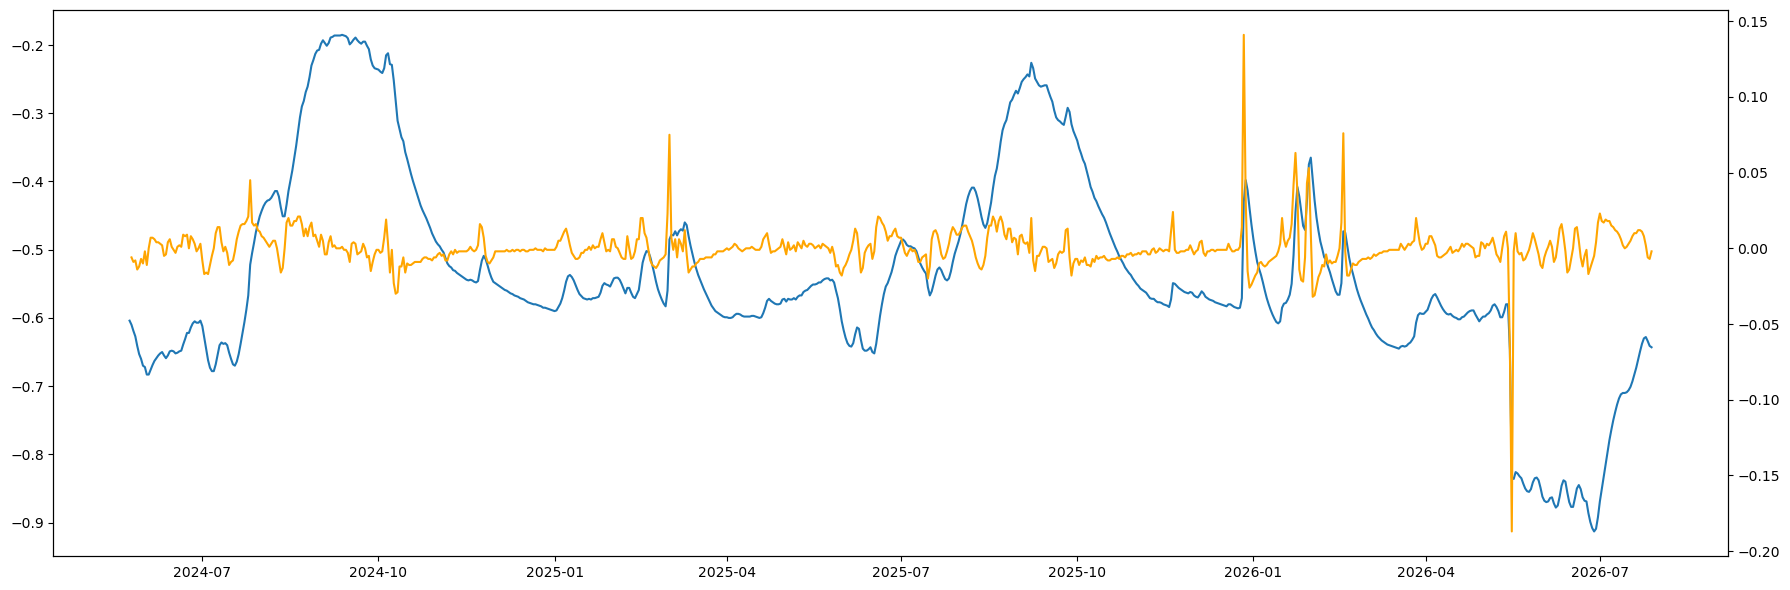

In [13]:
fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(sdh1.index, sdh1['SDH1PS01_gw-depth_m'])
ax2 = ax1.twinx()
ax2.plot(sdh1_diff.index, sdh1_diff['SDH1PS01_gw-depth_m'], color='orange')

plt.tight_layout()
plt.show()

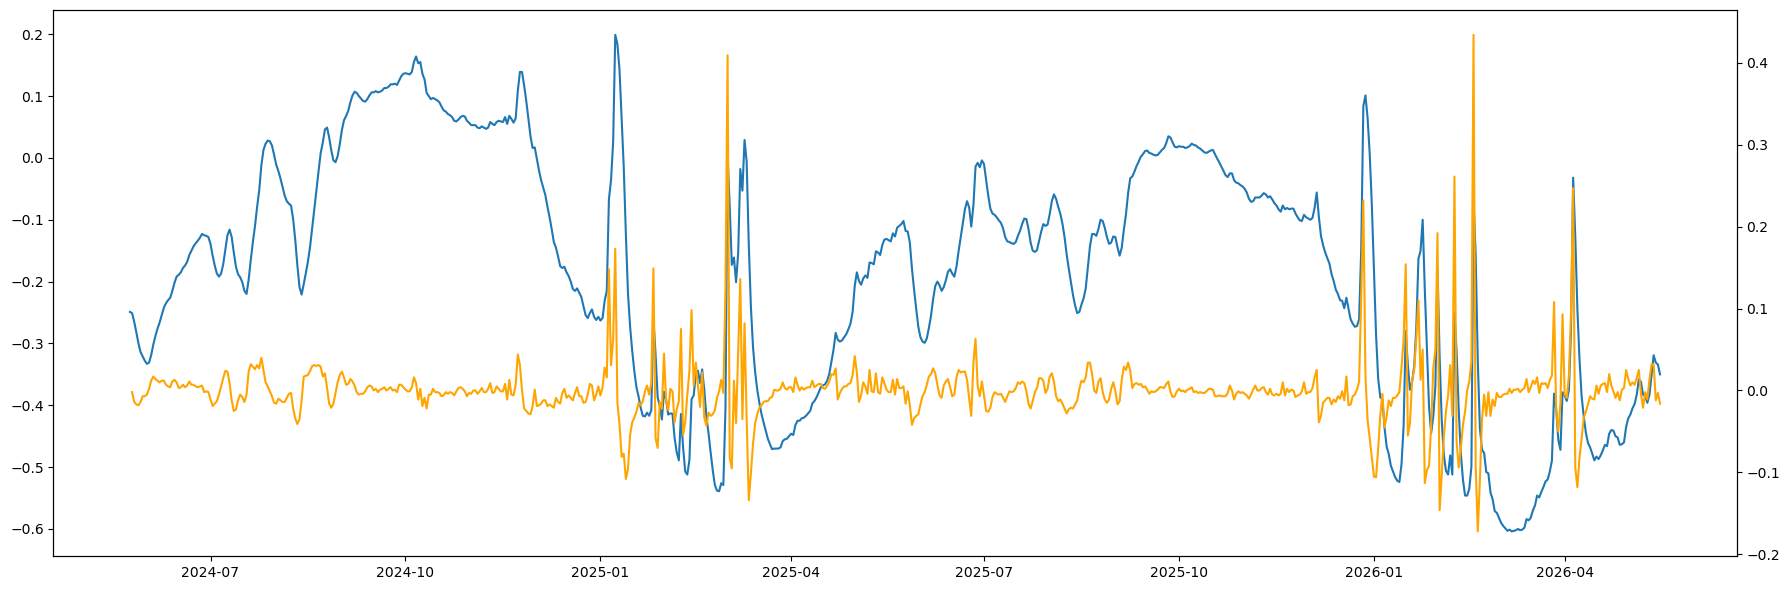

In [14]:
fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(sdh2.index, sdh2['SDH2PP01_gw-depth_m'])
ax2 = ax1.twinx()
ax2.plot(sdh2_diff.index, sdh2_diff['SDH2PP01_gw-depth_m'], color='orange')

plt.tight_layout()
plt.show()

#### Reconstrucción a partir de valor conocido y diferencia

In [15]:
# Ultimo nivel conocido (SDH1PS01 2026-05-17)
ref_level = -0.56

# Inversion cronologica de valores diferenciados (presente > pasado)
sdh1_diff_reversed = sdh1_diff.iloc[::-1]

# Generacion de nueva serie como la resta de la suma acumulada + las diferencias invertidas
sdh1_rebuilt = ref_level - sdh1_diff_reversed.cumsum() + sdh1_diff_reversed
sdh1_rebuilt = sdh1_rebuilt.iloc[::-1]

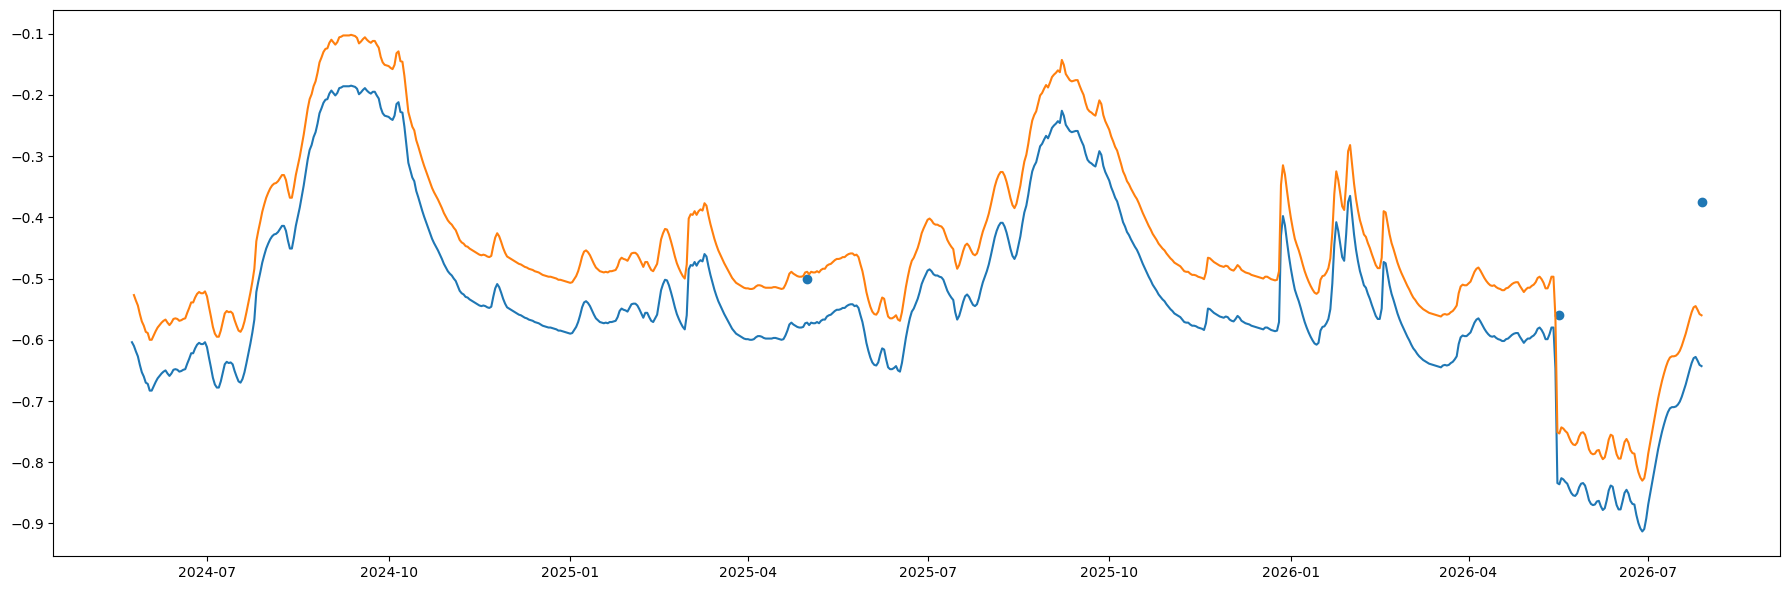

In [16]:
fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(sdh1.index, sdh1['SDH1PS01_gw-depth_m'])
ax1.plot(sdh1_rebuilt.index, sdh1_rebuilt['SDH1PS01_gw-depth_m'])
# ax1.plot(sdh1.index, sdh1['SDH1PS02_gw-depth_m'])
# ax1.plot(sdh1.index, sdh1['SDH1PS03_gw-depth_m'])
# ax1.plot(sdh1.index, sdh1['SDH1PS04_gw-depth_m'])

ax1.scatter(manual_obs.index, manual_obs['SDH1PS01'])
# ax1.scatter(manual_obs.index, manual_obs['SDH1PS02'])
# ax1.scatter(manual_obs.index, manual_obs['SDH1PS03'])
# ax1.scatter(manual_obs.index, manual_obs['SDH1PS04'])


plt.tight_layout()
plt.show()

In [17]:
# Ultimo nivel conocido (SDH2PP01 2026-05-16)
ref_level = -0.39

# Inversion cronologica de valores diferenciados (presente > pasado)
sdh2_diff_reversed = sdh2_diff.iloc[::-1]

# Generacion de nueva serie como la resta de la suma acumulada + las diferencias invertidas
sdh2_rebuilt = ref_level - sdh2_diff_reversed.cumsum() + sdh2_diff_reversed
sdh2_rebuilt = sdh2_rebuilt.iloc[::-1]

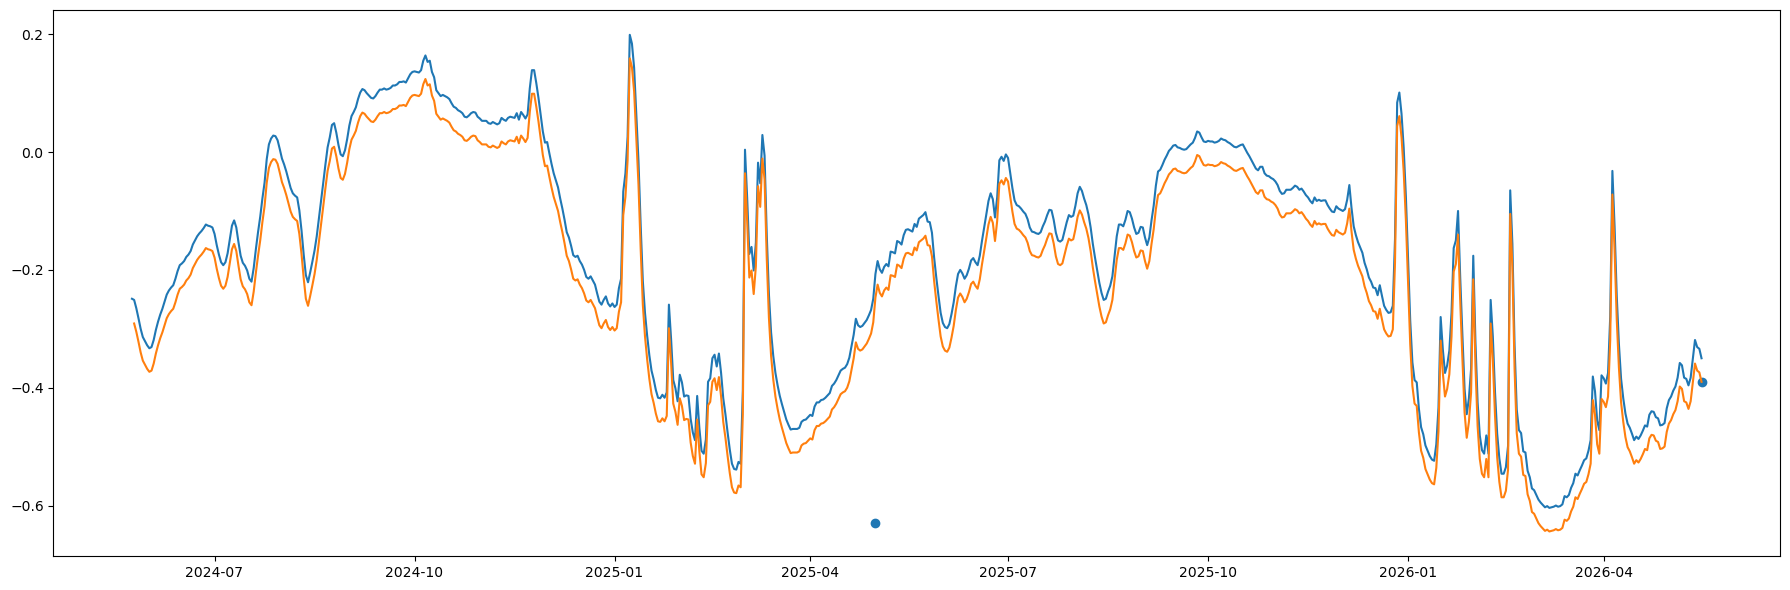

In [18]:
fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(sdh2.index, sdh2['SDH2PP01_gw-depth_m'])
ax1.plot(sdh2_rebuilt.index, sdh2_rebuilt['SDH2PP01_gw-depth_m'])

ax1.scatter(manual_obs.index, manual_obs['SDH2PP01'])

plt.tight_layout()
plt.show()